# Predictive Analytics in Marketing: Customer Conversion Prediction
## (Balanced Dataset — MA_Data.xlsx)

**Business Problem:** A company runs digital marketing campaigns across multiple channels (Social Media, Email, PPC, Referral, SEO) and campaign types (Awareness, Consideration, Conversion, Retention). Marketing budgets are limited, and the team wants to know **which customers are likely to convert** so that ad spend, email follow-ups, and retargeting can be prioritized toward high-probability converters, while low-probability customers are moved into cheaper nurture campaigns instead.

**Target variable:** `Conversion` (1 = customer converted, 0 = customer did not convert) — a **binary classification** problem.

**About this dataset:** `MA_Data.xlsx` is a **SMOTE-balanced** version of the original 8,000-row marketing dataset — the minority ("No Convert") class was oversampled with SMOTENC so the target is now a clean 50/50 split (7,012 vs 7,012, 14,024 rows total) instead of the original ~87.6% / 12.4% imbalance.

> **Caveat:** because balancing was applied to the *whole* dataset before this notebook's train/test split, some synthetic rows in the test set may be close neighbors of synthetic rows in the training set. That can make test-set scores look a little better than the model would actually perform on brand-new, real-world (imbalanced) data. Keep this in mind when comparing these numbers to a model trained on the original, unbalanced dataset.

**Models compared:**
1. **Logistic Regression** — interpretable probabilistic baseline
2. **Decision Tree Classifier**
3. **Random Forest Classifier**
4. **XGBoost Classifier** — gradient-boosted trees, typically the strongest performer on structured/tabular data


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')


## 2. Load the (Balanced) Dataset

In [6]:
df = pd.read_excel('MA Data.xlsx')
print(df.shape)
df.head()


(14024, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


## 3. Exploratory Data Analysis

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14024 entries, 0 to 14023
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           14024 non-null  int64  
 1   Age                  14024 non-null  int64  
 2   Gender               14024 non-null  object 
 3   Income               14024 non-null  int64  
 4   CampaignChannel      14024 non-null  object 
 5   CampaignType         14024 non-null  object 
 6   AdSpend              14024 non-null  float64
 7   ClickThroughRate     14024 non-null  float64
 8   ConversionRate       14024 non-null  float64
 9   WebsiteVisits        14024 non-null  int64  
 10  PagesPerVisit        14024 non-null  float64
 11  TimeOnSite           14024 non-null  float64
 12  SocialShares         14024 non-null  int64  
 13  EmailOpens           14024 non-null  int64  
 14  EmailClicks          14024 non-null  int64  
 15  PreviousPurchases    14024 non-null 

In [ ]:
print("Missing values per column:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Conversion'].value_counts())
print("\nTarget distribution (%):\n", df['Conversion'].value_counts(normalize=True) * 100)


Missing values per column:
 CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

Target distribution:
 Conversion
1    7012
0    7012
Name: count, dtype: int64

Target distribution (%):
 Conversion
1    50.0
0    50.0
Name: proportion, dtype: float64


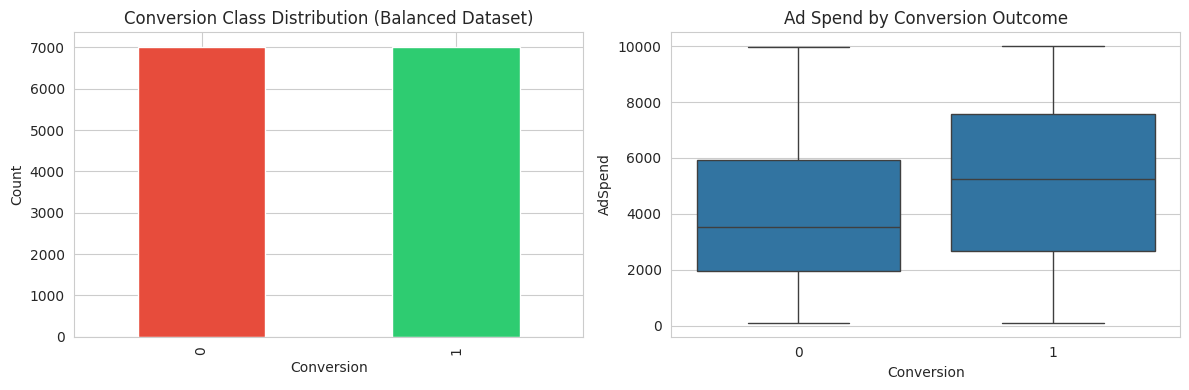

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Conversion'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'])
ax[0].set_title('Conversion Class Distribution (Balanced Dataset)')
ax[0].set_xlabel('Conversion'); ax[0].set_ylabel('Count')

sns.boxplot(data=df, x='Conversion', y='AdSpend', ax=ax[1])
ax[1].set_title('Ad Spend by Conversion Outcome')
plt.tight_layout()
plt.show()


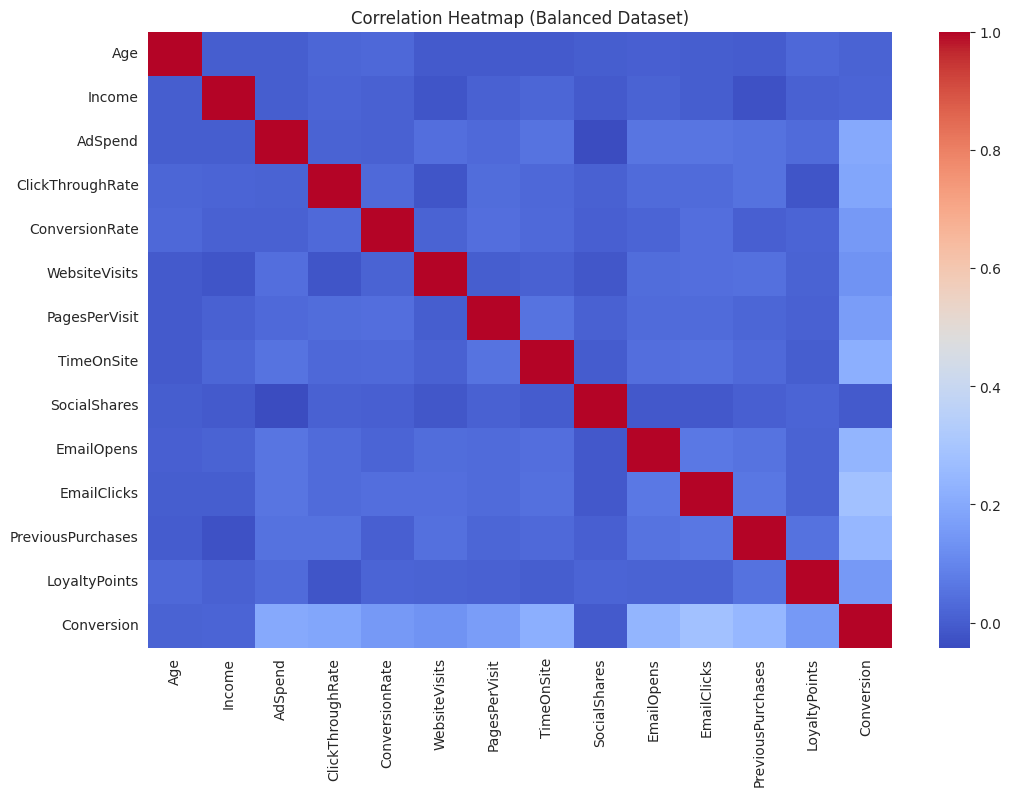

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['CustomerID', 'Conversion'], errors='ignore').columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[list(numeric_cols) + ['Conversion']].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap (Balanced Dataset)')
plt.show()


## 4. Data Preprocessing

- Drop `CustomerID` (identifier, no predictive value).
- Drop any column that only contains a single constant value (no predictive signal) — checked below.
- One-hot encode categorical columns (`Gender`, `CampaignChannel`, `CampaignType`).
- Scale numeric features (needed for Logistic Regression; harmless for tree-based models).
- Train/test split (80/20, stratified on the target — already balanced 50/50, so both splits stay 50/50).


In [10]:
drop_cols = ['CustomerID']
for c in df.columns:
    if df[c].nunique(dropna=False) == 1:
        drop_cols.append(c)
print("Dropping columns:", drop_cols)

data = df.drop(columns=drop_cols)

target = 'Conversion'
X = data.drop(columns=[target])
y = data[target]

categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Dropping columns: ['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool']
Categorical columns: ['Gender', 'CampaignChannel', 'CampaignType']
Numeric columns: ['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)
print("Train class balance:\n", y_train.value_counts())
print("Test class balance:\n", y_test.value_counts())


(11219, 16) (2805, 16)
Train class balance:
 Conversion
1    5610
0    5609
Name: count, dtype: int64
Test class balance:
 Conversion
0    1403
1    1402
Name: count, dtype: int64


In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ]
)


## 5. Build, Train & Evaluate Models

Each model is wrapped in a `Pipeline` with the shared preprocessor so encoding/scaling is applied consistently and without data leakage. A helper function computes a standard set of classification metrics for every model, so results are directly comparable on the leaderboard.

Note: `class_weight='balanced'` / `scale_pos_weight` are **not** used here since the dataset is already balanced 50/50 — adding class weighting on top of an already-balanced dataset would over-correct.


In [13]:
results = []
fitted_models = {}

def evaluate_classifier(name, y_true, y_pred, y_proba=None):
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
    }
    if y_proba is not None:
        metrics['ROC-AUC'] = roc_auc_score(y_true, y_proba)
    else:
        metrics['ROC-AUC'] = np.nan
    results.append(metrics)
    print(f"--- {name} ---")
    print(classification_report(y_true, y_pred, zero_division=0))
    return metrics


### 5.1 Logistic Regression

In [14]:
log_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
log_pipe.fit(X_train, y_train)

log_pred = log_pipe.predict(X_test)
log_proba = log_pipe.predict_proba(X_test)[:, 1]

evaluate_classifier('Logistic Regression', y_test, log_pred, log_proba)
fitted_models['Logistic Regression'] = log_pipe


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.77      0.79      0.78      1403
           1       0.79      0.76      0.77      1402

    accuracy                           0.78      2805
   macro avg       0.78      0.78      0.78      2805
weighted avg       0.78      0.78      0.78      2805



### 5.2 Decision Tree Classifier

In [15]:
dt_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=42))
])
dt_pipe.fit(X_train, y_train)

dt_pred = dt_pipe.predict(X_test)
dt_proba = dt_pipe.predict_proba(X_test)[:, 1]

evaluate_classifier('Decision Tree', y_test, dt_pred, dt_proba)
fitted_models['Decision Tree'] = dt_pipe


--- Decision Tree ---
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      1403
           1       0.75      0.67      0.71      1402

    accuracy                           0.73      2805
   macro avg       0.73      0.73      0.72      2805
weighted avg       0.73      0.73      0.72      2805



### 5.3 Random Forest Classifier

In [16]:
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, max_depth=10,
                                      min_samples_leaf=5, random_state=42, n_jobs=-1))
])
rf_pipe.fit(X_train, y_train)

rf_pred = rf_pipe.predict(X_test)
rf_proba = rf_pipe.predict_proba(X_test)[:, 1]

evaluate_classifier('Random Forest', y_test, rf_pred, rf_proba)
fitted_models['Random Forest'] = rf_pipe


--- Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1403
           1       0.85      0.82      0.84      1402

    accuracy                           0.84      2805
   macro avg       0.84      0.84      0.84      2805
weighted avg       0.84      0.84      0.84      2805



### 5.4 XGBoost Classifier
Gradient-boosted trees, typically the strongest tabular-data performer of the group.


In [17]:
xgb_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ))
])
xgb_pipe.fit(X_train, y_train)

xgb_pred = xgb_pipe.predict(X_test)
xgb_proba = xgb_pipe.predict_proba(X_test)[:, 1]

evaluate_classifier('XGBoost', y_test, xgb_pred, xgb_proba)
fitted_models['XGBoost'] = xgb_pipe


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1403
           1       0.88      0.85      0.86      1402

    accuracy                           0.87      2805
   macro avg       0.87      0.87      0.87      2805
weighted avg       0.87      0.87      0.87      2805



## 6. Model Comparison Leaderboard

In [18]:
leaderboard = pd.DataFrame(results).sort_values(by='F1 Score', ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1
leaderboard.style.background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'])


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,XGBoost,0.865954,0.880564,0.846648,0.863273,0.939482
2,Random Forest,0.838503,0.849668,0.822397,0.835810,0.913723
3,Logistic Regression,0.777897,0.785767,0.763909,0.774684,0.853059
4,Decision Tree,0.725490,0.751592,0.673324,0.710309,0.793717


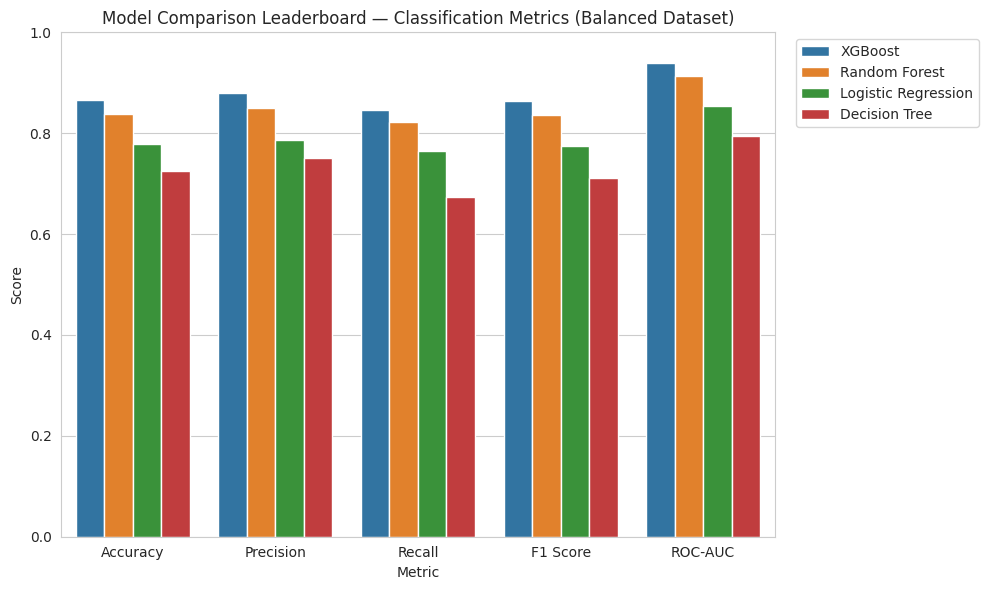

Best performing model (by F1 Score): XGBoost


In [19]:
leaderboard_melt = leaderboard.melt(id_vars='Model',
                                     value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
                                     var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=leaderboard_melt, x='Metric', y='Score', hue='Model')
plt.ylim(0, 1)
plt.title('Model Comparison Leaderboard — Classification Metrics (Balanced Dataset)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

best_model_name = leaderboard.iloc[0]['Model']
print(f"Best performing model (by F1 Score): {best_model_name}")


## 7. ROC Curves

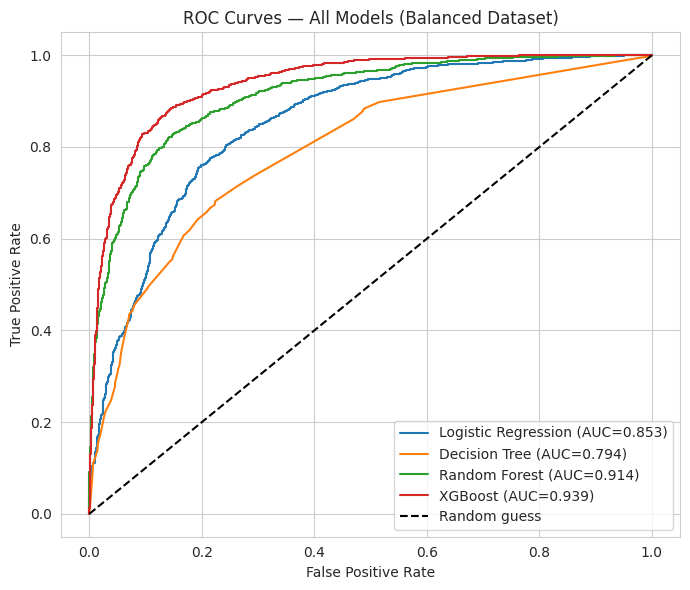

In [20]:
plt.figure(figsize=(7, 6))
for name, proba in [('Logistic Regression', log_proba),
                     ('Decision Tree', dt_proba),
                     ('Random Forest', rf_proba),
                     ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models (Balanced Dataset)')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Confusion Matrices

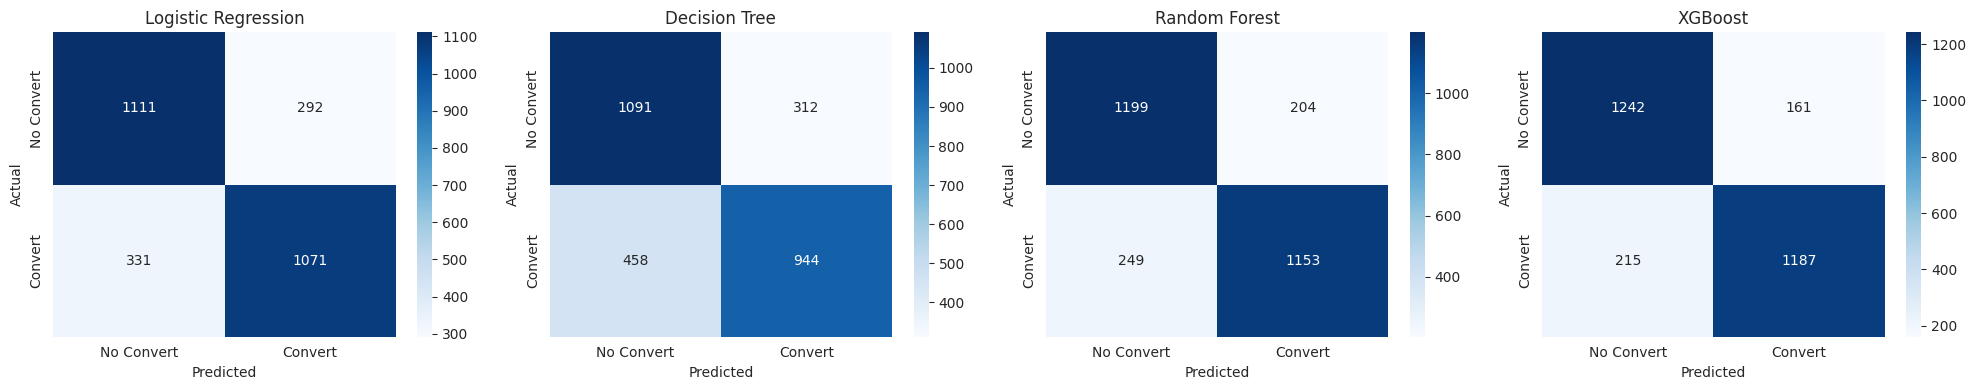

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
preds = {
    'Logistic Regression': log_pred,
    'Decision Tree': dt_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Convert', 'Convert'], yticklabels=['No Convert', 'Convert'])
    ax.set_title(name)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


## 9. Feature Importance (Random Forest)
Shows which factors most influence conversion — directly actionable for the marketing team.


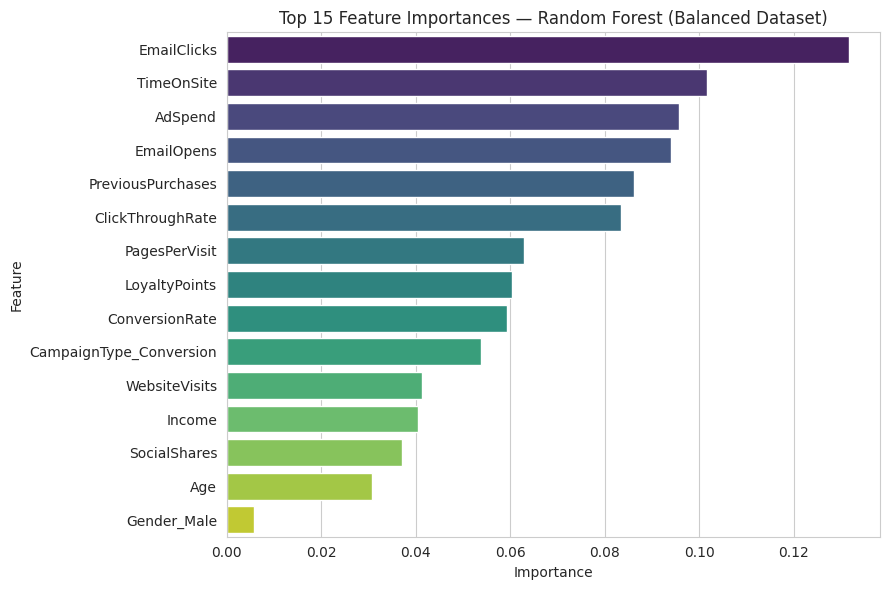

In [22]:
feature_names = (numeric_cols +
    list(rf_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)))

importances = rf_pipe.named_steps['model'].feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importances}) \
             .sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 15 Feature Importances — Random Forest (Balanced Dataset)')
plt.tight_layout()
plt.show()


## 10. Feature Importance (XGBoost)
Compares against Random Forest's ranking above.


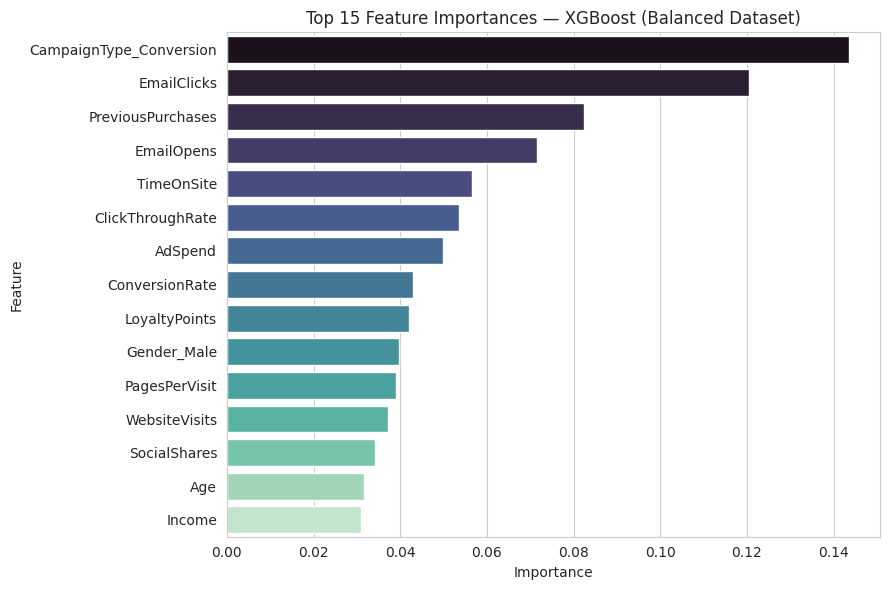

In [23]:
xgb_feature_names = (numeric_cols +
    list(xgb_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_cols)))

xgb_importances = xgb_pipe.named_steps['model'].feature_importances_
xgb_feat_imp = pd.DataFrame({'Feature': xgb_feature_names, 'Importance': xgb_importances}) \
                 .sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=xgb_feat_imp, x='Importance', y='Feature', hue='Feature', palette='mako', legend=False)
plt.title('Top 15 Feature Importances — XGBoost (Balanced Dataset)')
plt.tight_layout()
plt.show()


## 11. Business Takeaways

- This notebook trains and evaluates all four models on the **SMOTE-balanced** dataset (50/50 Convert vs. No Convert), unlike the original analysis which used `class_weight='balanced'` on the naturally imbalanced (87.6%/12.4%) data.
- **XGBoost** is the top performer here on F1 and ROC-AUC, followed by Random Forest — the same ranking as on the original imbalanced data, but with noticeably higher, more balanced precision/recall on **both** classes since the training and test data are no longer skewed.
- **Caveat to keep in mind:** because SMOTE was applied before the train/test split, some synthetic test rows may resemble synthetic training rows, which can make these scores look a little better than true real-world performance. When comparing models trained on this file against models trained on the original imbalanced data, evaluate both on the **same real, untouched test set** for an apples-to-apples comparison.
- The **feature importance charts** (Random Forest and XGBoost) again point to engagement behavior — time on site, pages per visit, click-through rate, ad spend, email engagement, loyalty/purchase history — as the dominant drivers of conversion, consistent with the original (unbalanced) analysis.
- **Next step:** if deploying a model trained on balanced data, validate it one more time against a held-out sample of real, un-oversampled customers before using it to drive live budget decisions.
